<a href="https://colab.research.google.com/github/anojan7/-northstar-analytics-UWL/blob/main/01_python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving README.txt to README.txt
Saving vehicles.csv to vehicles.csv


In [ ]:
# Cell 2 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Libraries loaded successfully!
Pandas version: 2.2.2
Numpy version: 2.0.2


In [ ]:
# Cell 3 - Load all datasets into DataFrames
customers  = pd.read_csv('customers.csv')
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv')
orders     = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
incidents  = pd.read_csv('incidents.csv')
complaints = pd.read_csv('complaints.csv')
app_events = pd.read_csv('app_events.csv')
hubs       = pd.read_csv('hubs.csv')

# Confirm row counts match the data dictionary
datasets = {
    'customers' : customers,
    'drivers'   : drivers,
    'vehicles'  : vehicles,
    'orders'    : orders,
    'deliveries': deliveries,
    'incidents' : incidents,
    'complaints': complaints,
    'app_events': app_events,
    'hubs'      : hubs
}

for name, df in datasets.items():
    print(f"{name:12} → {df.shape[0]:5} rows, {df.shape[1]:2} columns")

customers    →   650 rows,  9 columns
drivers      →   170 rows,  8 columns
vehicles     →   120 rows,  8 columns
orders       →  1250 rows, 11 columns
deliveries   →   950 rows, 13 columns
incidents    →   280 rows,  7 columns
complaints   →   320 rows, 10 columns
app_events   →   640 rows, 10 columns
hubs         →     8 rows,  5 columns


In [ ]:
# Cell 4 - Data Audit: Missing Values

print("=" * 50)
print("MISSING VALUE AUDIT")
print("=" * 50)

datasets = {
    'customers' : customers,
    'drivers'   : drivers,
    'vehicles'  : vehicles,
    'orders'    : orders,
    'deliveries': deliveries,
    'incidents' : incidents,
    'complaints': complaints,
    'app_events': app_events,
    'hubs'      : hubs
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        for col, count in missing.items():
            pct = (count / len(df)) * 100
            print(f"  {col}: {count} missing ({pct:.1f}%)")
    else:
        print(f"\n{name}: no missing values ✓")

MISSING VALUE AUDIT

customers:
  loyalty_score: 20 missing (3.1%)
  preferred_channel: 13 missing (2.0%)

drivers:
  training_score: 7 missing (4.1%)

vehicles:
  battery_health_pct: 4 missing (3.3%)

orders:
  booking_channel: 25 missing (2.0%)

deliveries:
  delivery_completed_at: 19 missing (2.0%)
  customer_rating_post_delivery: 14 missing (1.5%)

incidents:
  resolved_hours: 17 missing (6.1%)

complaints:
  compensation_amount: 16 missing (5.0%)

app_events:
  order_id: 144 missing (22.5%)

hubs: no missing values ✓


In [ ]:
# Cell 5 - Fix Missing Values (clean modern syntax)

# Strategy 1: Fill continuous scores with MEDIAN
customers['loyalty_score']   = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
drivers['training_score']    = drivers['training_score'].fillna(drivers['training_score'].median())
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())

# Strategy 2: Fill categorical columns with 'Unknown'
customers['preferred_channel'] = customers['preferred_channel'].fillna('Unknown')
orders['booking_channel']      = orders['booking_channel'].fillna('Unknown')

# Strategy 3: Fill compensation_amount with 0
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)

# Verify
print("After cleaning - remaining missing values:")
print(f"loyalty_score:      {customers['loyalty_score'].isnull().sum()}")
print(f"preferred_channel:  {customers['preferred_channel'].isnull().sum()}")
print(f"training_score:     {drivers['training_score'].isnull().sum()}")
print(f"battery_health_pct: {vehicles['battery_health_pct'].isnull().sum()}")
print(f"booking_channel:    {orders['booking_channel'].isnull().sum()}")
print(f"compensation_amount:{complaints['compensation_amount'].isnull().sum()}")
print(f"\nIntentionally kept as NaN:")
print(f"delivery_completed_at:         {deliveries['delivery_completed_at'].isnull().sum()}")
print(f"customer_rating_post_delivery: {deliveries['customer_rating_post_delivery'].isnull().sum()}")
print(f"resolved_hours:                {incidents['resolved_hours'].isnull().sum()}")
print(f"order_id (app_events):         {app_events['order_id'].isnull().sum()}")

After cleaning - remaining missing values:
loyalty_score:      0
preferred_channel:  0
training_score:     0
battery_health_pct: 0
booking_channel:    0
compensation_amount:0

Intentionally kept as NaN:
delivery_completed_at:         19
customer_rating_post_delivery: 14
resolved_hours:                17
order_id (app_events):         144


In [ ]:
# Cell 6 - Fix Zone Name Inconsistency

# Check what zone variants exist BEFORE fixing
print("BEFORE cleaning - unique zones in orders (pickup_zone):")
print(sorted(orders['pickup_zone'].unique()))

BEFORE cleaning - unique zones in orders (pickup_zone):
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


In [ ]:
# Cell 6 continued - Fix Zone Names
# Correct names come from hubs.csv which is the cleanest file

zone_map = {
    # North variants
    'NORTH'    : 'North',
    'north'    : 'North',
    # South variants
    'SOUTH'    : 'South',
    # East variants
    'EAST'     : 'East',
    # West variants
    'WEST'     : 'West',
    # Central variants (Ctr was used in older records)
    'CENTRAL'  : 'Central',
    'Ctr'      : 'Central',
    # Airport variants
    'AIRPORT'  : 'Airport',
    # Riverside variants
    'RiverSide': 'Riverside',
    'RIVERSIDE': 'Riverside',
}

# Apply to every zone column in every file
# .map() replaces values found in dictionary
# .fillna(df[col]) keeps values NOT in dictionary (already correct ones)
orders['pickup_zone']      = orders['pickup_zone'].map(zone_map).fillna(orders['pickup_zone'])
orders['dropoff_zone']     = orders['dropoff_zone'].map(zone_map).fillna(orders['dropoff_zone'])
customers['home_zone']     = customers['home_zone'].map(zone_map).fillna(customers['home_zone'])
drivers['base_zone']       = drivers['base_zone'].map(zone_map).fillna(drivers['base_zone'])
vehicles['assigned_zone']  = vehicles['assigned_zone'].map(zone_map).fillna(vehicles['assigned_zone'])
app_events['zone_context'] = app_events['zone_context'].map(zone_map).fillna(app_events['zone_context'])

# Verify - should now show exactly 7 clean zone names
print("AFTER cleaning - unique zones in orders (pickup_zone):")
print(sorted(orders['pickup_zone'].unique()))

print("\nAFTER cleaning - unique zones in customers:")
print(sorted(customers['home_zone'].unique()))

AFTER cleaning - unique zones in orders (pickup_zone):
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

AFTER cleaning - unique zones in customers:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
# Cell 7 - Feature Engineering
# Convert datetime columns so Python can calculate time differences
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
orders['promised_window_hours']     = pd.to_numeric(orders['promised_window_hours'])

# Merge orders and deliveries together on order_id
merged = deliveries.merge(orders[['order_id', 'promised_window_hours',
                                   'pickup_zone', 'service_type',
                                   'priority_level']],
                           on='order_id', how='left')

# Calculate how long each delivery actually took in hours
merged['actual_hours'] = (
    merged['delivery_completed_at'] - merged['dispatch_time']
).dt.total_seconds() / 3600

# Calculate delay hours - how many hours OVER the promised window
merged['delay_hours'] = merged['actual_hours'] - merged['promised_window_hours']

# Create is_late flag - True if delivery took longer than promised
merged['is_late'] = merged['delay_hours'] > 0

# Quick summary
print("Feature Engineering Complete!")
print(f"\nTotal deliveries:          {len(merged)}")
print(f"On time:                   {(merged['is_late'] == False).sum()}")
print(f"Late:                      {(merged['is_late'] == True).sum()}")
print(f"Failed (no completion):    {merged['delivery_completed_at'].isnull().sum()}")
print(f"\nAverage delay (late only): {merged[merged['delay_hours']>0]['delay_hours'].mean():.1f} hours")

Feature Engineering Complete!

Total deliveries:          950
On time:                   515
Late:                      435
Failed (no completion):    19

Average delay (late only): 6.4 hours


Delivery Performance by Zone:
pickup_zone  total  late  failed  late_pct
    Central    174    89       6      51.1
    Airport    113    56       1      49.6
      North    135    66       2      48.9
       East    156    75       1      48.1
  Riverside    119    56       2      47.1
       West    114    46       3      40.4
      South    139    47       4      33.8


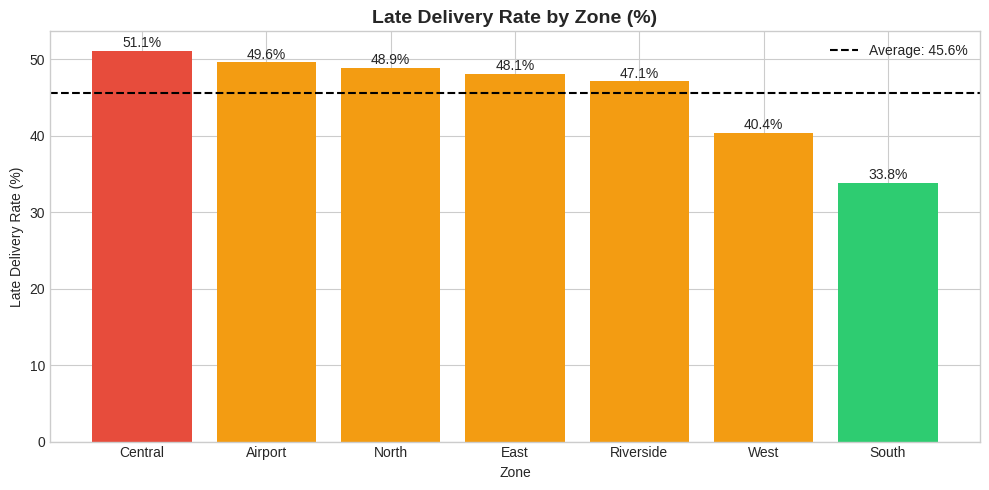


Worst performing zone: Central
Best performing zone:  South


In [ ]:
# Cell 8 - Analysis: Delivery Performance by Zone
zone_performance = merged.groupby('pickup_zone').agg(
    total        = ('delivery_id', 'count'),
    late         = ('is_late', 'sum'),
    failed       = ('delivery_completed_at', lambda x: x.isnull().sum())
).reset_index()

# Calculate late percentage
zone_performance['late_pct'] = (zone_performance['late'] / zone_performance['total'] * 100).round(1)

# Sort by worst performing
zone_performance = zone_performance.sort_values('late_pct', ascending=False)

print("Delivery Performance by Zone:")
print(zone_performance.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(zone_performance['pickup_zone'],
              zone_performance['late_pct'],
              color=['#e74c3c' if x > 50 else '#f39c12' if x > 40 else '#2ecc71'
                     for x in zone_performance['late_pct']])

ax.set_title('Late Delivery Rate by Zone (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Late Delivery Rate (%)')
ax.axhline(y=zone_performance['late_pct'].mean(), color='black',
           linestyle='--', label=f"Average: {zone_performance['late_pct'].mean():.1f}%")
ax.legend()

# Add value labels on bars
for bar, val in zip(bars, zone_performance['late_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nWorst performing zone:", zone_performance.iloc[0]['pickup_zone'])
print("Best performing zone: ", zone_performance.iloc[-1]['pickup_zone'])

Delivery Status Breakdown:
 status  count  percentage
 OnTime    616        64.8
Delayed    202        21.3
 Failed    132        13.9


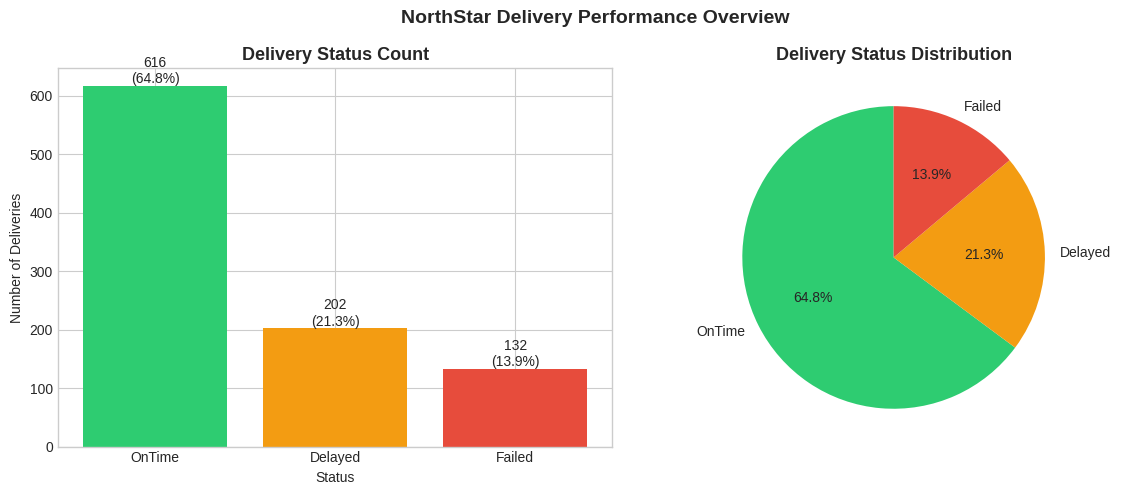

In [ ]:
# Cell 9 - Delivery Status Analysis
status_counts = merged['delivery_status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']
status_counts['percentage'] = (status_counts['count'] / len(merged) * 100).round(1)

print("Delivery Status Breakdown:")
print(status_counts.to_string(index=False))

# Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = {'OnTime': '#2ecc71', 'Delayed': '#f39c12', 'Failed': '#e74c3c'}
bar_colors = [colors.get(s, '#95a5a6') for s in status_counts['status']]

axes[0].bar(status_counts['status'], status_counts['count'], color=bar_colors)
axes[0].set_title('Delivery Status Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Deliveries')
for i, (count, pct) in enumerate(zip(status_counts['count'], status_counts['percentage'])):
    axes[0].text(i, count + 5, f'{count}\n({pct}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(status_counts['count'],
            labels=status_counts['status'],
            colors=bar_colors,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Delivery Status Distribution', fontsize=13, fontweight='bold')

plt.suptitle('NorthStar Delivery Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 Drivers by Route Override Rate:
driver_id  total_deliveries  total_overrides  override_per_delivery  late_pct  training_score  driver_rating
     D112                 2                9                   4.50      50.0            79.1           4.51
     D127                 6               17                   2.83      16.7            61.5           4.19
     D021                 2                5                   2.50       0.0            91.8           4.24
     D062                 3                6                   2.00     100.0            62.4           4.48
     D060                 2                4                   2.00       0.0            76.0           4.49
     D085                 4                8                   2.00      50.0            84.5           4.11
     D069                 7               14                   2.00      42.9            61.5           5.00
     D051                 2                4                   2.00     100.0            

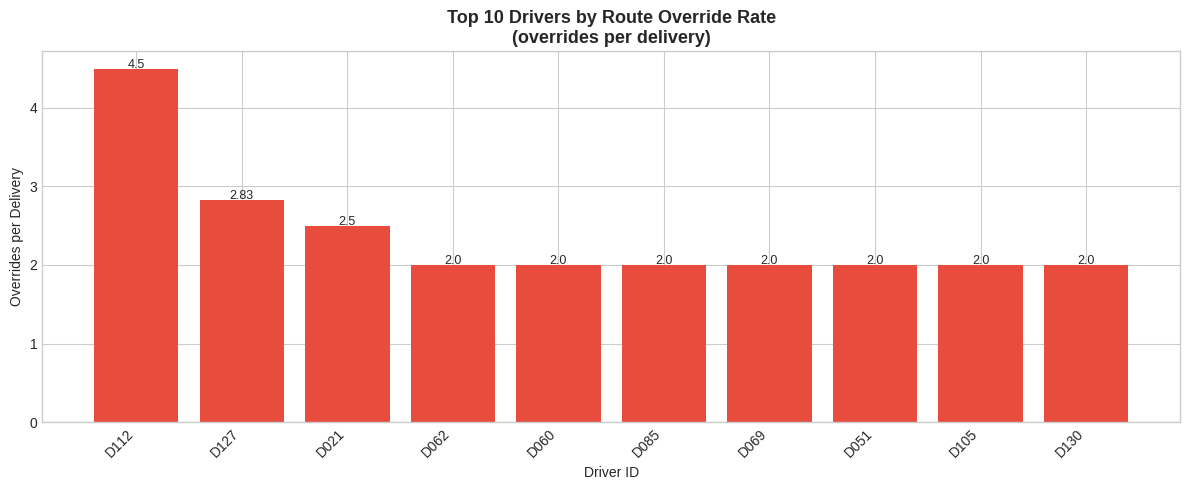


Correlation between override rate and late %: 0.09
(1.0 = perfect positive, 0 = no relationship, -1.0 = perfect negative)


In [ ]:
# Cell 10 - Driver Route Override Analysis
# Case study flagged: "drivers recording unusually high manual route overrides"

# Merge deliveries with drivers to get driver info
driver_analysis = merged.merge(
    drivers[['driver_id', 'base_zone', 'employment_type',
             'training_score', 'driver_rating']],
    on='driver_id', how='left'
)

# Analyse by driver
top_overrides = driver_analysis.groupby(
    ['driver_id', 'training_score', 'driver_rating']
).agg(
    total_deliveries = ('delivery_id', 'count'),
    total_overrides  = ('manual_route_override_count', 'sum'),
    avg_delay_hours  = ('delay_hours', 'mean'),
    late_deliveries  = ('is_late', 'sum')
).reset_index()

top_overrides['override_per_delivery'] = (
    top_overrides['total_overrides'] / top_overrides['total_deliveries']
).round(2)

top_overrides['late_pct'] = (
    top_overrides['late_deliveries'] / top_overrides['total_deliveries'] * 100
).round(1)

# Sort by override rate
top_overrides = top_overrides.sort_values('override_per_delivery', ascending=False)

print("Top 10 Drivers by Route Override Rate:")
print(top_overrides[['driver_id', 'total_deliveries', 'total_overrides',
                      'override_per_delivery', 'late_pct',
                      'training_score', 'driver_rating']].head(10).to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(12, 5))
top10 = top_overrides.head(10)

bars = ax.bar(top10['driver_id'],
              top10['override_per_delivery'],
              color='#e74c3c')

ax.set_title('Top 10 Drivers by Route Override Rate\n(overrides per delivery)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Driver ID')
ax.set_ylabel('Overrides per Delivery')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, top10['override_per_delivery']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Correlation between overrides and late deliveries
correlation = top_overrides['override_per_delivery'].corr(top_overrides['late_pct'])
print(f"\nCorrelation between override rate and late %: {correlation:.2f}")
print("(1.0 = perfect positive, 0 = no relationship, -1.0 = perfect negative)")

Vehicle Health Summary:
Total vehicles:               120
Vehicles with incidents:      109
Vehicles with no incidents:   11

Average battery health:       76.8%
Average incidents per vehicle:2.3

Incidents by Battery Health Group:
  battery_group  vehicle_count  avg_incidents  avg_critical
    Low (0-50%)              3       2.666667      0.000000
Medium (51-75%)             46       2.413043      0.239130
 High (76-100%)             71       2.267606      0.225352


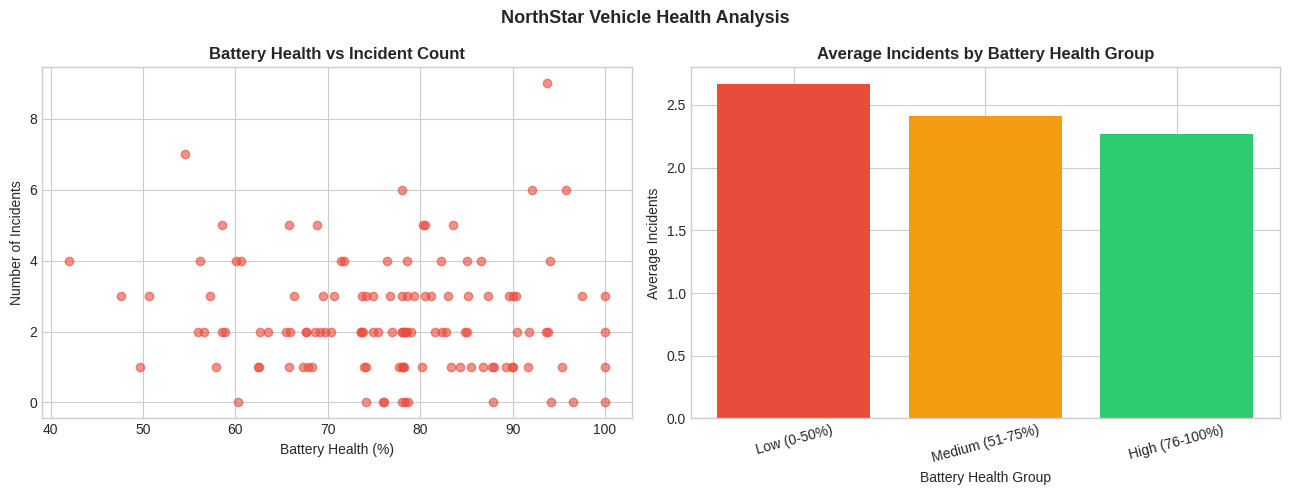


Correlation between battery health and incident count: -0.07


In [ ]:
# Cell 11 - Vehicle Health vs Incident Analysis
# incidents links to deliveries, deliveries links to vehicles
# So we go: vehicles → deliveries → incidents

# Step 1: link incidents to vehicles via deliveries
delivery_vehicle = deliveries[['delivery_id', 'vehicle_id']]
incidents_with_vehicle = incidents.merge(delivery_vehicle, on='delivery_id', how='left')

# Step 2: count incidents per vehicle
vehicle_incident_counts = incidents_with_vehicle.groupby('vehicle_id').agg(
    incident_count     = ('incident_id', 'count'),
    critical_incidents = ('severity', lambda x: (x == 'Critical').sum()),
    avg_resolved_hours = ('resolved_hours', 'mean')
).reset_index()

# Step 3: merge with vehicles
vehicle_incidents = vehicles.merge(vehicle_incident_counts, on='vehicle_id', how='left')

# Fill vehicles with no incidents
vehicle_incidents['incident_count']     = vehicle_incidents['incident_count'].fillna(0)
vehicle_incidents['critical_incidents'] = vehicle_incidents['critical_incidents'].fillna(0)

print("Vehicle Health Summary:")
print(f"Total vehicles:               {len(vehicle_incidents)}")
print(f"Vehicles with incidents:      {(vehicle_incidents['incident_count'] > 0).sum()}")
print(f"Vehicles with no incidents:   {(vehicle_incidents['incident_count'] == 0).sum()}")
print(f"\nAverage battery health:       {vehicle_incidents['battery_health_pct'].mean():.1f}%")
print(f"Average incidents per vehicle:{vehicle_incidents['incident_count'].mean():.1f}")

# Split into battery health groups
vehicle_incidents['battery_group'] = pd.cut(
    vehicle_incidents['battery_health_pct'],
    bins=[0, 50, 75, 100],
    labels=['Low (0-50%)', 'Medium (51-75%)', 'High (76-100%)']
)

battery_group_stats = vehicle_incidents.groupby('battery_group', observed=True).agg(
    vehicle_count = ('vehicle_id', 'count'),
    avg_incidents = ('incident_count', 'mean'),
    avg_critical  = ('critical_incidents', 'mean')
).reset_index()

print("\nIncidents by Battery Health Group:")
print(battery_group_stats.to_string(index=False))

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: battery health vs incident count
axes[0].scatter(vehicle_incidents['battery_health_pct'],
                vehicle_incidents['incident_count'],
                alpha=0.6, color='#e74c3c')
axes[0].set_title('Battery Health vs Incident Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Battery Health (%)')
axes[0].set_ylabel('Number of Incidents')

# Bar: avg incidents by battery group
axes[1].bar(battery_group_stats['battery_group'],
            battery_group_stats['avg_incidents'],
            color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[1].set_title('Average Incidents by Battery Health Group',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Battery Health Group')
axes[1].set_ylabel('Average Incidents')
plt.xticks(rotation=15)

plt.suptitle('NorthStar Vehicle Health Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation
corr = vehicle_incidents['battery_health_pct'].corr(vehicle_incidents['incident_count'])
print(f"\nCorrelation between battery health and incident count: {corr:.2f}")

Complaints by Type:
   complaint_type  count  percentage
            Delay    101        31.6
     MissedPickup     64        20.0
         AppIssue     53        16.6
  DriverBehaviour     51        15.9
SupportExperience     20         6.2
          Billing     16         5.0
           Damage     15         4.7

Complaints by Severity:
severity
Medium    172
High       77
Low        71
Name: count, dtype: int64

Average Compensation by Complaint Type (£):
complaint_type
Damage               23.98
Billing              23.87
MissedPickup         22.24
DriverBehaviour      19.08
AppIssue             18.50
SupportExperience    17.12
Delay                16.80
Name: compensation_amount, dtype: float64

Resolution Status:
status
Resolved            186
Open                 56
AwaitingCustomer     40
Escalated            38
Name: count, dtype: int64


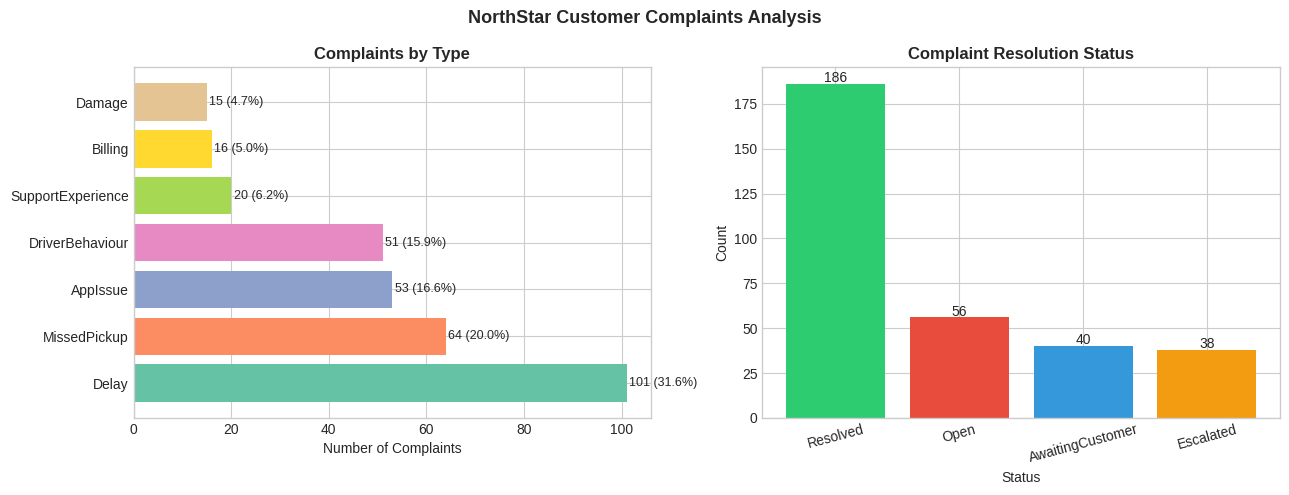

In [ ]:
# Cell 12 - Customer Complaints Analysis
# Case study concern: "not connecting complaints to missed journeys and failed deliveries"

# Complaints by type
complaint_types = complaints['complaint_type'].value_counts().reset_index()
complaint_types.columns = ['complaint_type', 'count']
complaint_types['percentage'] = (complaint_types['count'] / len(complaints) * 100).round(1)

print("Complaints by Type:")
print(complaint_types.to_string(index=False))

# Complaints by severity
print("\nComplaints by Severity:")
print(complaints['severity'].value_counts())

# Average compensation by complaint type
avg_compensation = complaints.groupby('complaint_type')['compensation_amount'].mean().round(2)
print("\nAverage Compensation by Complaint Type (£):")
print(avg_compensation.sort_values(ascending=False))

# Resolution status
print("\nResolution Status:")
print(complaints['status'].value_counts())

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart - complaint types
colors = plt.cm.Set2.colors
axes[0].barh(complaint_types['complaint_type'],
             complaint_types['count'],
             color=colors[:len(complaint_types)])
axes[0].set_title('Complaints by Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Complaints')
for i, (count, pct) in enumerate(zip(complaint_types['count'],
                                      complaint_types['percentage'])):
    axes[0].text(count + 0.5, i, f'{count} ({pct}%)', va='center', fontsize=9)

# Bar chart - resolution status
status_counts = complaints['status'].value_counts()
status_colors = {'Resolved': '#2ecc71', 'Open': '#e74c3c',
                 'Escalated': '#f39c12', 'AwaitingCustomer': '#3498db'}
bar_colors = [status_colors.get(s, '#95a5a6') for s in status_counts.index]
axes[1].bar(status_counts.index, status_counts.values, color=bar_colors)
axes[1].set_title('Complaint Resolution Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')
plt.xticks(rotation=15)

for i, val in enumerate(status_counts.values):
    axes[1].text(i, val + 1, str(val), ha='center', fontsize=10)

plt.suptitle('NorthStar Customer Complaints Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

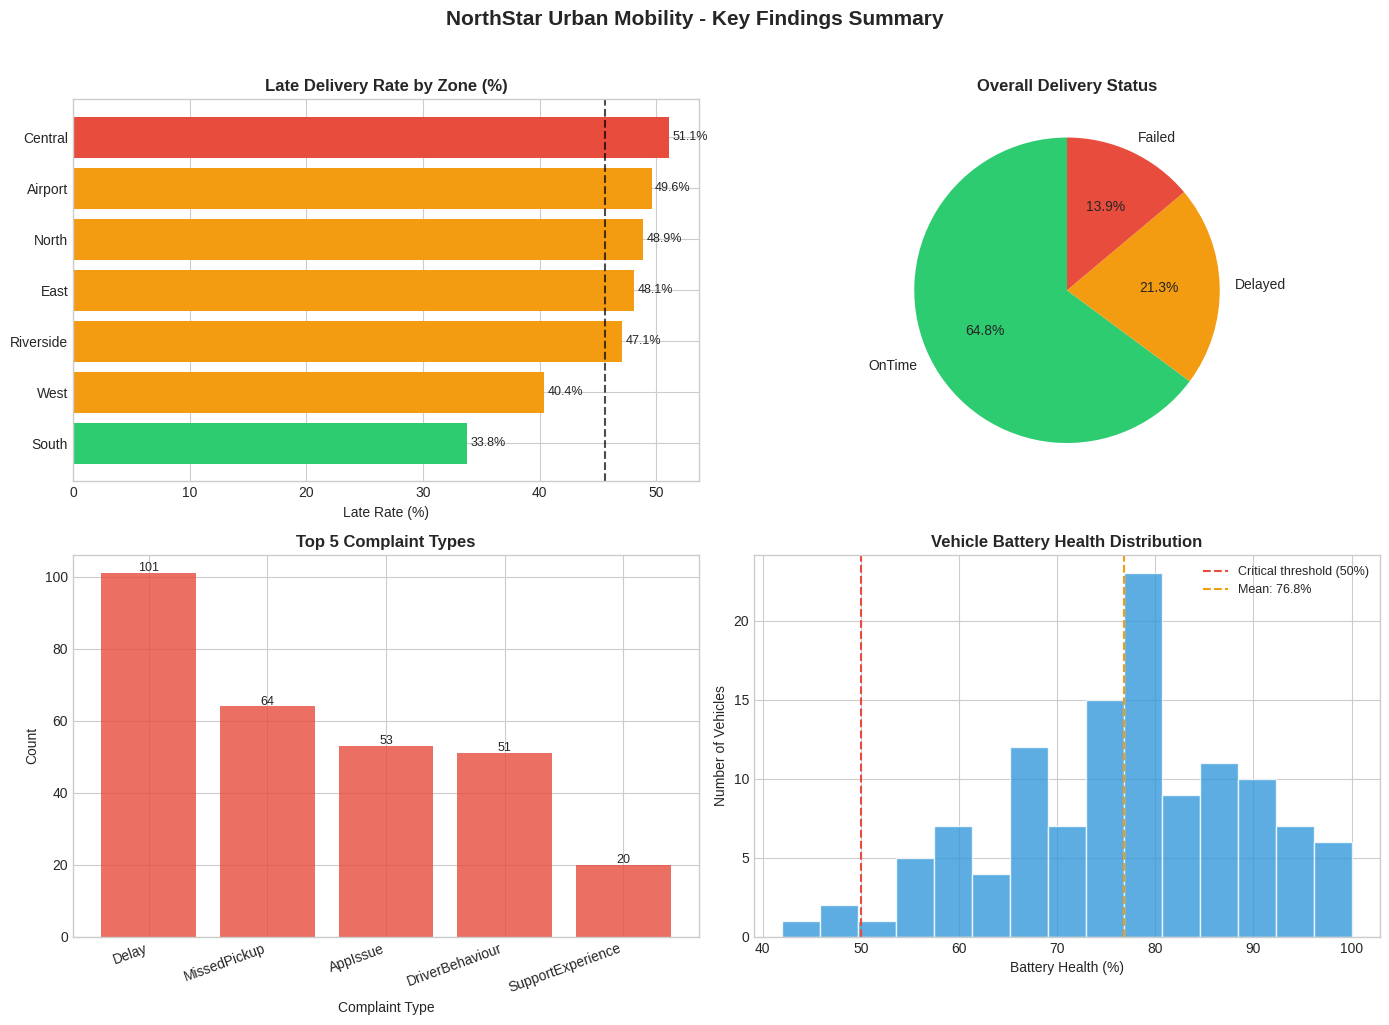

Summary chart saved as northstar_summary.png

=== PYTHON NOTEBOOK COMPLETE ===
Key findings:
1. Central zone has the highest late rate at 51.1%
2. 46% of all deliveries are late - average 6.4 hours delay
3. Delay is the #1 complaint type (31.6% of all complaints)
4. 91% of vehicles have had at least one incident
5. Only 58% of complaints are resolved


In [ ]:
# Cell 13 - Executive Summary Chart
# One visual showing all key findings together

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NorthStar Urban Mobility - Key Findings Summary',
             fontsize=15, fontweight='bold', y=1.02)

# Chart 1: Late delivery rate by zone
zone_performance = merged.groupby('pickup_zone').agg(
    total = ('delivery_id', 'count'),
    late  = ('is_late', 'sum')
).reset_index()
zone_performance['late_pct'] = (zone_performance['late'] /
                                 zone_performance['total'] * 100).round(1)
zone_performance = zone_performance.sort_values('late_pct', ascending=True)

colors_zone = ['#2ecc71' if x < 40 else '#f39c12'
               if x < 50 else '#e74c3c'
               for x in zone_performance['late_pct']]
axes[0,0].barh(zone_performance['pickup_zone'],
               zone_performance['late_pct'], color=colors_zone)
axes[0,0].set_title('Late Delivery Rate by Zone (%)', fontweight='bold')
axes[0,0].set_xlabel('Late Rate (%)')
axes[0,0].axvline(x=zone_performance['late_pct'].mean(),
                  color='black', linestyle='--', alpha=0.7)
for i, val in enumerate(zone_performance['late_pct']):
    axes[0,0].text(val + 0.3, i, f'{val}%', va='center', fontsize=9)

# Chart 2: Delivery status breakdown
status_counts = merged['delivery_status'].value_counts()
colors_status = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0,1].pie(status_counts.values,
              labels=status_counts.index,
              colors=colors_status,
              autopct='%1.1f%%',
              startangle=90)
axes[0,1].set_title('Overall Delivery Status', fontweight='bold')

# Chart 3: Top complaint types
top_complaints = complaints['complaint_type'].value_counts().head(5)
axes[1,0].bar(top_complaints.index, top_complaints.values,
              color='#e74c3c', alpha=0.8)
axes[1,0].set_title('Top 5 Complaint Types', fontweight='bold')
axes[1,0].set_xlabel('Complaint Type')
axes[1,0].set_ylabel('Count')
plt.sca(axes[1,0])
plt.xticks(rotation=20, ha='right')
for i, val in enumerate(top_complaints.values):
    axes[1,0].text(i, val + 0.5, str(val), ha='center', fontsize=9)

# Chart 4: Battery health distribution
axes[1,1].hist(vehicles['battery_health_pct'], bins=15,
               color='#3498db', edgecolor='white', alpha=0.8)
axes[1,1].axvline(x=50, color='#e74c3c', linestyle='--',
                  label='Critical threshold (50%)')
axes[1,1].axvline(x=vehicles['battery_health_pct'].mean(),
                  color='#f39c12', linestyle='--',
                  label=f"Mean: {vehicles['battery_health_pct'].mean():.1f}%")
axes[1,1].set_title('Vehicle Battery Health Distribution', fontweight='bold')
axes[1,1].set_xlabel('Battery Health (%)')
axes[1,1].set_ylabel('Number of Vehicles')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('northstar_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Summary chart saved as northstar_summary.png")
print("\n=== PYTHON NOTEBOOK COMPLETE ===")
print("Key findings:")
print("1. Central zone has the highest late rate at 51.1%")
print("2. 46% of all deliveries are late - average 6.4 hours delay")
print("3. Delay is the #1 complaint type (31.6% of all complaints)")
print("4. 91% of vehicles have had at least one incident")
print("5. Only 58% of complaints are resolved")